In [97]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.datasets import co2, get_rdataset
import hvplot.pandas
import hvplot as hv

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = [12, 5] 

In [98]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch9')
price = pd.read_csv(path / 'closing_price.csv')
price.head()

,Date,AAPL,MSFT,IBM
0,2019-11-01,62.830273,140.552994,115.847458
1,2019-11-04,63.242901,141.364731,117.676682
2,2019-11-05,63.152027,141.276733,117.864746
3,2019-11-06,63.179031,140.885513,118.625488
4,2019-11-07,63.908203,141.081116,119.083855


In [99]:
co2 = co2.load_pandas().data
co2 = co2.ffill()
co2.head()

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


In [101]:
air_passengers = get_rdataset("AirPassengers")
air_df = air_passengers.data
air_df.index = pd.date_range('1949','1961', freq='M')
air_df.drop(columns=['time'], inplace=True)
air_df.head()

/tmp/ipykernel_5957/2801627828.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  air_df.index = pd.date_range('1949','1961', freq='M')


,value
1949-01-31,112
1949-02-28,118
1949-03-31,132
1949-04-30,129
1949-05-31,121


<Axes: >

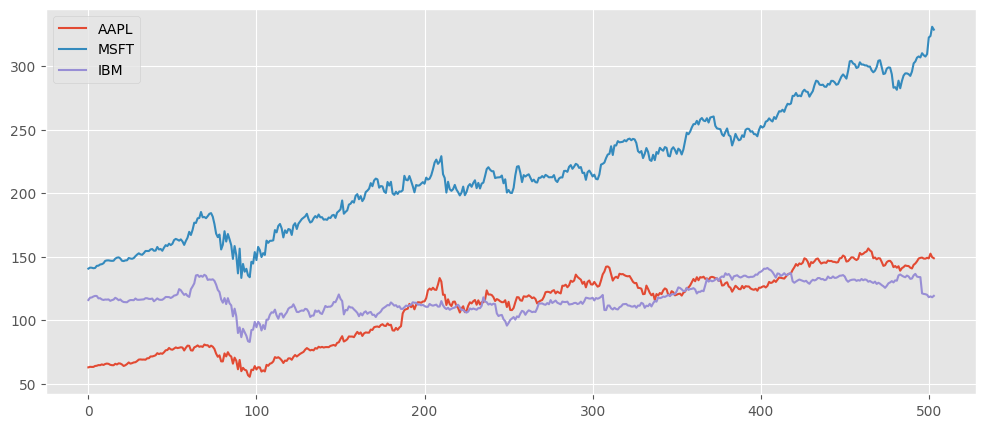

In [102]:
price.plot()

<Axes: >

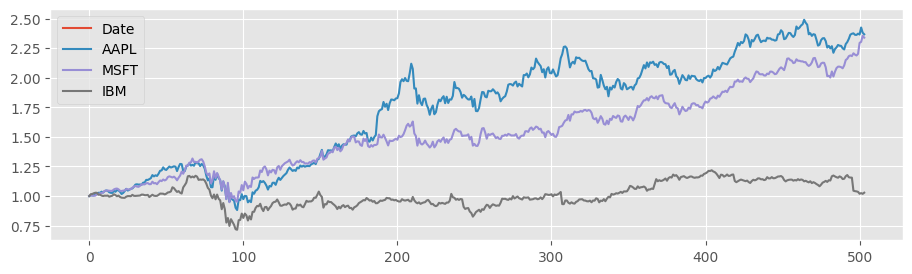

In [103]:
price = pd.DataFrame(price)

price = price.apply(pd.to_numeric, errors='coerce')

price_n = price.div(price.iloc[0])
price_n.plot(figsize=(11,3))

In [104]:
price_n.head()

,Date,AAPL,MSFT,IBM
0,NaN,1.000000,1.000000,1.000000
1,NaN,1.006567,1.005775,1.015790
2,NaN,1.005121,1.005149,1.017413
3,NaN,1.005551,1.002366,1.023980
4,NaN,1.017156,1.003757,1.027937


<Axes: >

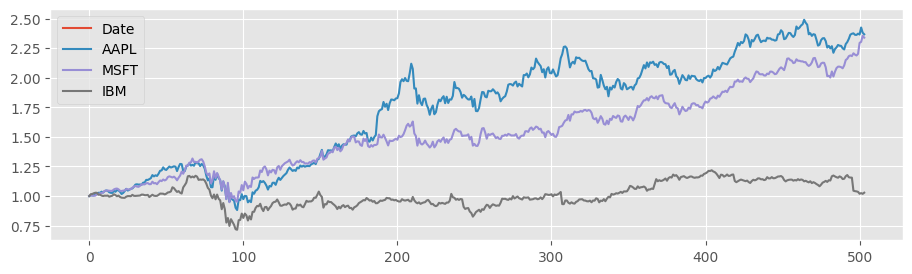

In [105]:
plt.style.use('ggplot')
price_n.plot(figsize=(11,3))

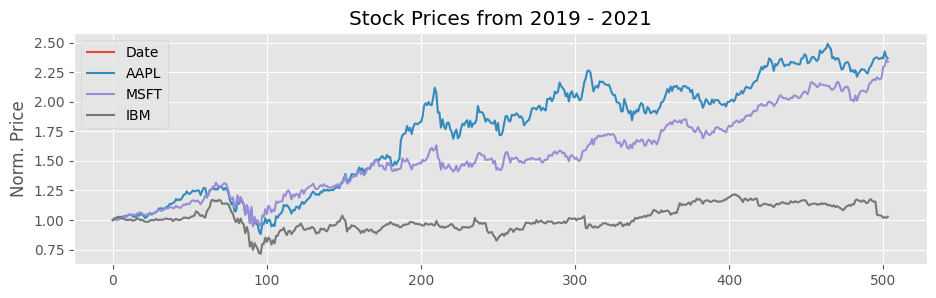

In [106]:
start_date = '2019'
end_date = '2021'

plot = price_n.plot(figsize=(11,3),
title=f'Stock Prices from {start_date} - {end_date}',
ylabel= 'Norm. Price')
plot.get_figure().savefig('plot_1.jpg')

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

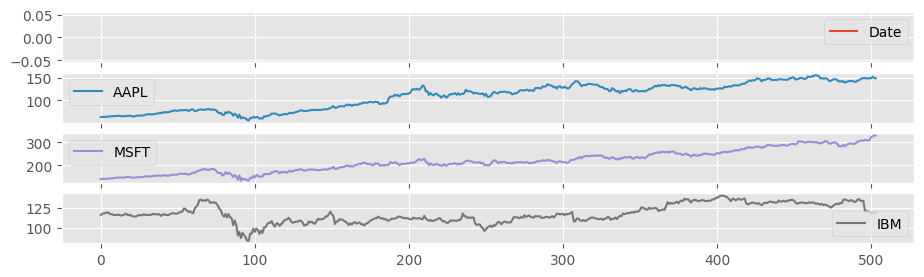

In [107]:
fig_dims = (11, 3)
price.plot(figsize=fig_dims, subplots=True)

In [108]:
price_n = price.div(price.iloc[0])

price_n.hvplot(title='Time Series plot using hvplot')

:NdOverlay   [Variable]
   :Curve   [index]   (value)

In [109]:
price_n.plot(backend='hvplot', title='Time Series plot using hvplot')

:NdOverlay   [Variable]
   :Curve   [index]   (value)

In [110]:
price_n.hvplot(width=300, subplots=True)

:NdLayout   [Variable]
   :Curve   [index]   (value)

In [111]:
price_n.hvplot(width=300, subplots=True).cols(2)

:NdLayout   [Variable]
   :Curve   [index]   (value)

In [112]:
(price_n['AAPL'].hvplot(width=400) + 
 price_n['MSFT'].hvplot(width=300))

:Layout
   .Curve.AAPL :Curve   [index]   (AAPL)
   .Curve.MSFT :Curve   [index]   (MSFT)

In [113]:
(price_n['AAPL'].hvplot(width=400) * 
 price_n['MSFT'].hvplot(width=300))

:Overlay
   .Curve.AAPL :Curve   [index]   (AAPL)
   .Curve.MSFT :Curve   [index]   (MSFT)

## Decomposing Time Series Data

### Seasonal-Trend decomposition with LOESS (STL)

In [114]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

plt.rcParams["figure.figsize"] = (10, 3)

<Axes: >

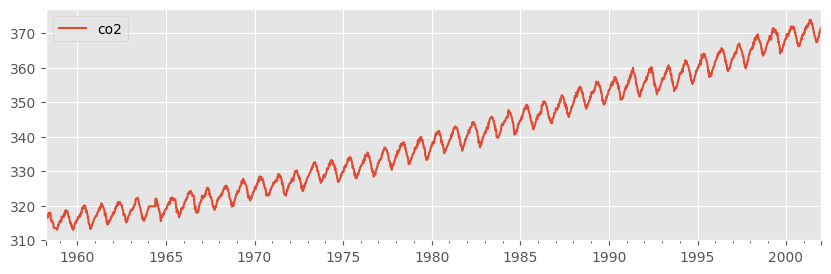

In [115]:
co2_df = pd.read_csv('/home/jeremy/Work/Data Science/Learning/Time Series/store-sales-time-series-forecasting/co2.csv')
# co2_df = co2.load_pandas().data
co2_df = co2_df.ffill()
co2.plot()

The plot above indicates an additive model because it is showing a long-term linear (upward) trend, with repeated seasonal pattern at a constant rate (Seasonal variation).

<Axes: >

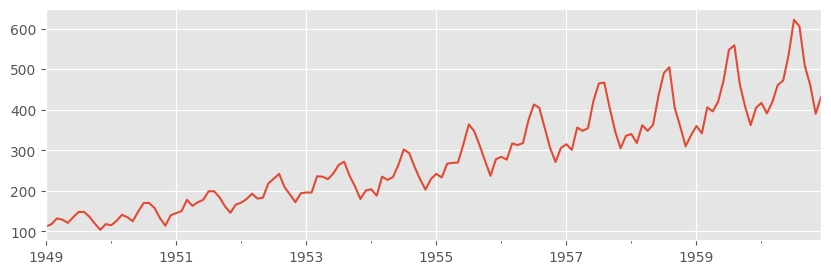

In [116]:
air_df['value'].plot()

The plot above shows a long-term linear (upward) trend and seasonality, thus it is a multiplicative model as the seasonality fluctuations seem to be increasing as well.

In [117]:
co2_df.columns

Index(['Date', 'CO2'], dtype='object')

In [118]:
## Convert 'Date' to datetime and set as index)
co2_df.columns = co2_df.columns.str.strip()
co2_df['date'] = pd.to_datetime(co2_df['Date'])
co2_df = co2_df.drop(columns=["Date"], axis=1)
co2_df.rename(columns={'date': 'Date'}, inplace=True)
co2_df.set_index('Date', inplace=True)
co2_df.head()

,CO2
Date,
1959-01-01,315.42
1959-02-01,316.31
1959-03-01,316.50
1959-04-01,317.56
1959-05-01,318.13


In [119]:
co2_decomposed = seasonal_decompose(co2_df, model='additive')
air_decomposed = seasonal_decompose(air_df, model='multiplicative')

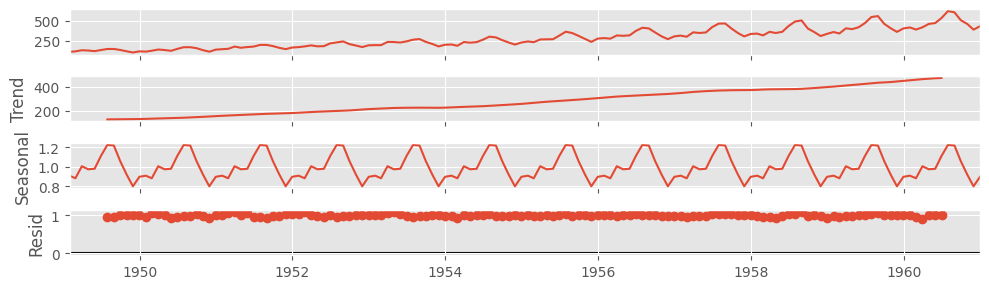

In [120]:
air_decomposed.plot(); plt.show()

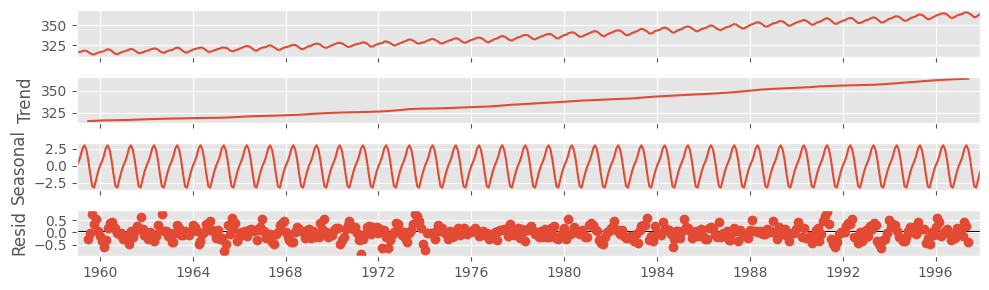

In [121]:
co2_decomposed.plot(); plt.show()

In [122]:
type(co2_decomposed)

statsmodels.tsa.seasonal.DecomposeResult

<Axes: >

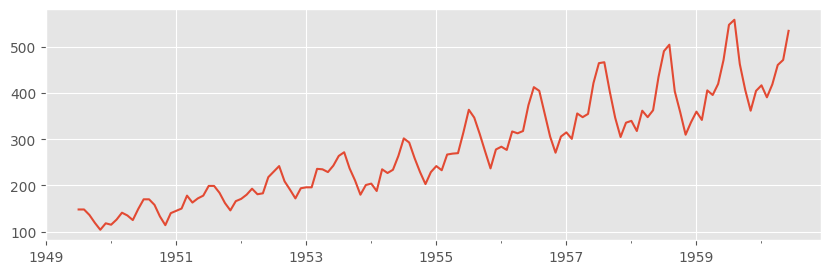

In [123]:
(air_decomposed.trend * air_decomposed.seasonal * air_decomposed.resid).plot()

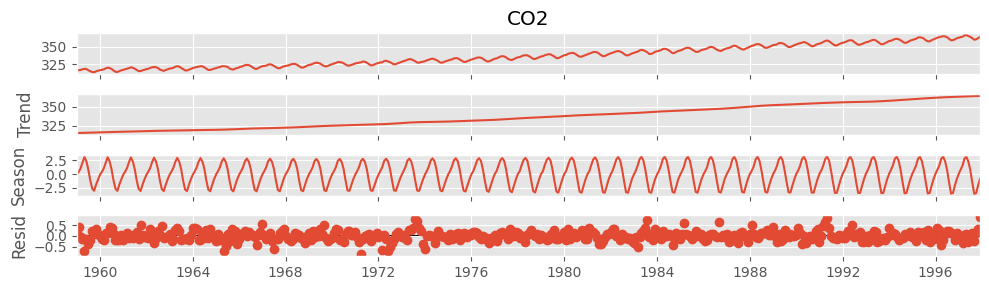

In [124]:
co2_stl = STL(
    co2_df['CO2'],
    seasonal=13,   # parameter for seasonal smoother and takes odd integers >= 7
    robust=True,   # set to True to help remove the impact of outliers on seasonal and trend components when calculated
).fit()

co2_stl.plot(); plt.show()

The STL class uses the **LOESS** seasonal smoother, which stands for **Locally Estimated**
**Scatterplot Smoothing** STL is more robust than ***seasonal_decompose*** for measuring
non-linear relationships. On the other hand, STL assumes additive composition, so you
do not need to indicate a model, unlike with ***seasonal_decompose***.

--------

The **Hodrick-Prescott filter** is a smoothing filter that can be used to separate short-term
fluctuations (cyclic variations) from long-term trends. This is implemented as ***hp_filter*** in the statsmodels library.

Recall that ***STL*** and ***seasonal_decompose*** returned three components (trend, seasonal, and residual). On the other hand, ***hp_filter*** returns two components: a cyclical component and a trend component.

In [125]:
from statsmodels.tsa.filters.hp_filter import hpfilter
plt.rcParams["figure.figsize"] = (20, 3)

co2_cyclic, co2_trend = hpfilter(co2_df)

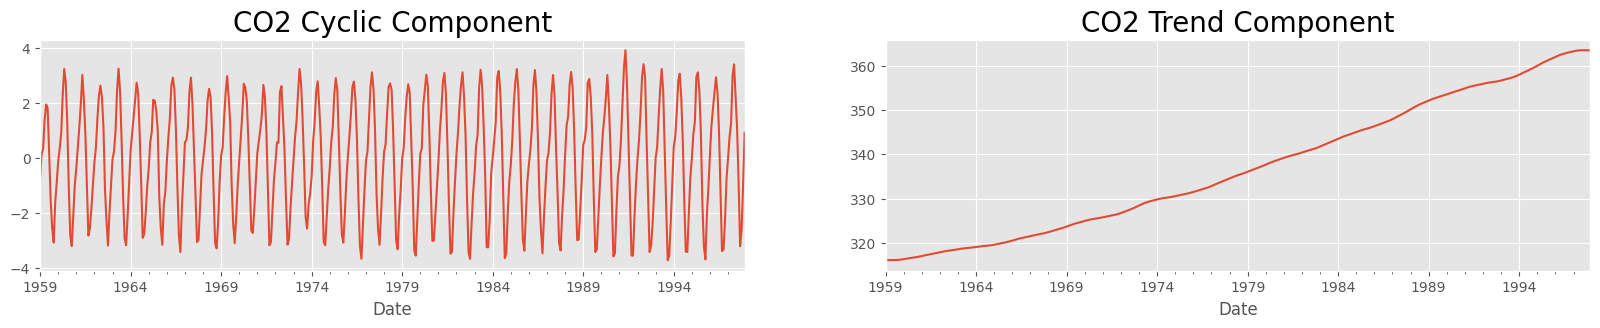

In [126]:
fig, ax = plt.subplots(1, 2)
co2_cyclic.plot(ax=ax[0], title='CO2 Cyclic Component')
co2_trend.plot(ax=ax[1], title='CO2 Trend Component')
ax[0].title.set_size(20); ax[1].title.set_size(20)

**Note** that the two components from hp_filter are additive. In other words, to
reconstruct the original time series, you would add co2_cyclic and co2_trend.

<Axes: xlabel='Date'>

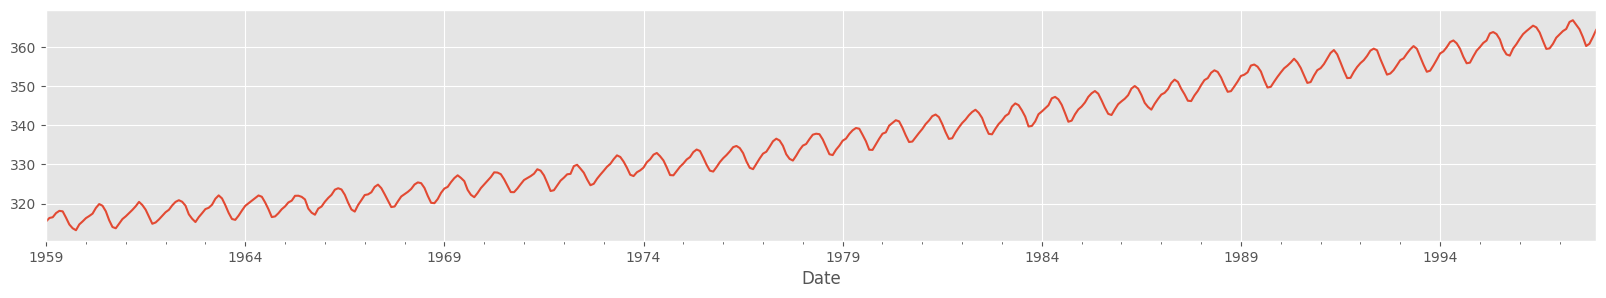

In [127]:
(co2_cyclic + co2_trend).plot()

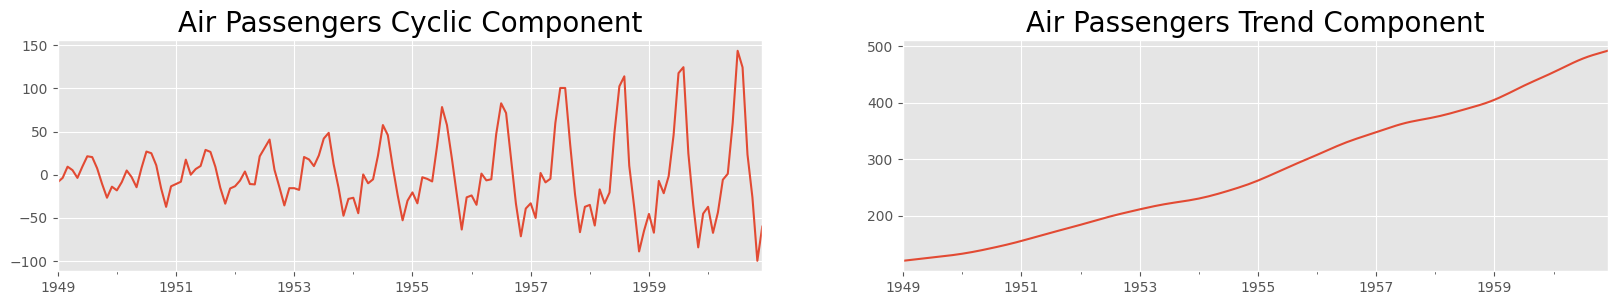

In [128]:
air_cyclic, air_trend = hpfilter(air_df)

fig, ax = plt.subplots(1, 2)
air_cyclic.plot(ax=ax[0], title='Air Passengers Cyclic Component')
air_trend.plot(ax=ax[1], title='Air Passengers Trend Component')
ax[0].title.set_size(20); ax[1].title.set_size(20)

<Axes: >

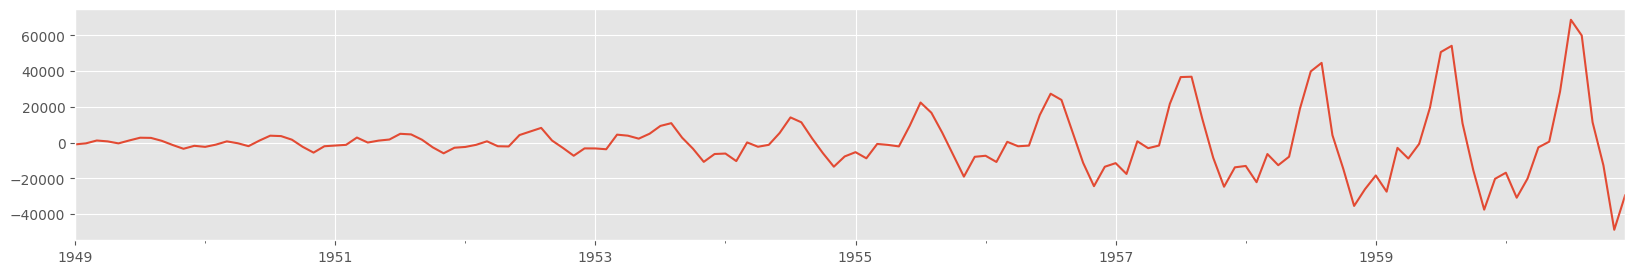

In [129]:
(air_cyclic * air_trend).plot()

## Detecting Time Stationarity

A stationary time series implies that specific statistical properties do not vary over time
and remain steady, making the processes easier to model and predict. On the other hand, a non-stationary process is more complex to model due to the dynamic nature and variations over time (for example, in the presence of trend or seasonality).

There are two approaches for defining stationarity: ***strong stationarity*** for strict models that may not be possible to observe and ***weak stationarity*** for models that are modest in criteria and can be observed.

In this recipe, and for practical reasons, a stationary time series is defined as a time
series with a constant mean (μ), a constant variance (σ2) , and a consistent covariance
(or autocorrelation) between identical distanced periods (lags). Having the mean and
variance as constants simplifies modeling since you are not solving for them as functions
of time.

Generally, a time series with trend or seasonality can be considered non-stationary. Usually,
spotting trends or seasonality visually in a plot can help you determine whether the time
series is stationary or not.

You will explore two statistical tests, the **Augmented Dickey-Fuller** (**ADF**) test and the
**Kwiatkowski-Phillips-Schmidt-Shin** (**KPSS**) test, using the statsmodels library. Both
ADF and KPSS test for unit roots in a univariate time series process. Note that unit roots
are just one cause for a time series to be non-stationary, but generally, the presence of unit
roots indicates non-stationarity.

Both ADF and KPSS are based on linear regression and are a type of statistical hypothesis
test. For example, the ***null hypothesis*** for ADF states that there is a unit root in the
time series, and thus, it is non-stationary. On the other hand, KPSS has the opposite
null hypothesis, which assumes the time series is stationary. Therefore, you will need
to interpret the test results to determine whether you can reject or fail to reject the null
hypothesis. Generally, you can rely on the p-values returned to decide whether you reject
or fail to reject the null hypothesis. Remember, the interpretation for ADF and KPSS
results is different given their opposite null hypotheses.

#### 1. ADFuller test

In [130]:
# ADFuller test
from statsmodels.tsa.stattools import adfuller, kpss

In [131]:
# Create a function that outputs the results in a user-friendly way.
def print_results(output, test):
    '''
    output: 
    test: the type of test, 'adf','kpss'
    '''
    p_value = output[1]
    test_score = output[0]
    lags = output[2]
    decision = 'Non-stationary'

    critical = []
    if test == 'adf':
        critical = output[4]
        if p_value < 0.05:
            decision = 'Stationary'
    elif test == 'kpss':
        critical = output[3]
        if p_value >= 0.05:
            decision = 'Stationary'
    
    output_dict = {
        'Test_Statistic': test_score,
        'p-value': p_value,
        'Numbers of Lags': lags,
        'decision': decision
    }

    for key, value in critical.items():
        output_dict["Critical Value {%s}" % key] = value

    return pd.Series(output_dict, name=test)

In [132]:
adf_output = adfuller(co2_df)
kpss_output = kpss(co2_df)

/tmp/ipykernel_5957/1069893886.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_output = kpss(co2_df)


In [133]:
pd.concat([
    print_results(adf_output, 'adf'),
    print_results(kpss_output, 'kpss')# Time series components plots
], axis=1)

,adf,kpss
Test_Statistic,2.32185,3.683945
p-value,0.998969,0.01
Numbers of Lags,13,12
decision,Non-stationary,Non-stationary
Critical Value {1%},-3.444836,0.739
Critical Value {5%},-2.867927,0.463
Critical Value {10%},-2.570172,0.347
Critical Value {2.5%},NaN,0.574


For **ADF**, the p-value is at 0.96, which is greater than 0.05, so you cannot reject
the null hypothesis, and therefore, the time series is non-stationary. For **KPSS**, the
p-value is at 0.01, which is less than 0.05, so you reject the null hypothesis, and
therefore, the time series is non-stationary.

You will explore six techniques for making the time series stationary, such as
transformations and differencing. The techniques covered are first-order differencing,
second-order differencing, subtracting moving average, log transformation,
decomposition, and Hodrick-Prescott filter.

Essentially, stationarity can be achieved by removing trend (detrending) and seasonality
effects. For each transformation, you will run the stationarity tests and compare the results
between the different techniques.

In [134]:
# check_stationarity function performs both KPSS and ADF tests and returns the outcome
def check_stationarity(df):
    '''
    df: dataframe
    '''
    kps = kpss(df)
    adf = adfuller(df)

    kpss_pv, adf_pv = kps[1], adf[1]
    kpssh, adfh = 'Stationary', 'Non-stationary'

    if adf_pv < 0.05:
        # Reject ADF Null hypothesis
        adfh = 'Stationary'

    if kpss_pv < 0.05:
        # Reject KPSS Null hypothesis
        kpssh = 'Non-stationary'

    return (kpssh, adfh)

In [135]:
# plot_comparison takes a list of methods and compares their plots. The
# function takes plot_type, so you can explore a line chart and a histogram. The
# function calls the check_stationarity function to capture the results for the
# subplot titles.
def plot_comparison(methods, plot_type='line'):
    '''
    methods: list of methods
    plot_type: type of plot i.e line, hist
    '''
    n = len(methods) // 2
    fig, ax = plt.subplots(n, 2, sharex=True, figsize=(20, 10))
    for i, method in enumerate(methods):
        method.dropna(inplace=True)
        name = [n for n in globals() if globals() [n] is method]
        v, r = i // 2, i % 2

        kpss_s, adf_s = check_stationarity(method)

        method.plot(
            kind=plot_type, 
            ax=ax[v,r],
            legend=False,
            title=f"{name[0]} --> KPSS: {kpss_s}, ADF: {adf_s}"
        )
        ax[v,r].title.set_size(20)
        method.rolling(window=52).mean().plot(ax=ax[v,r], legend=False)  # subtracting moving average with rolling window of 52. use diff() for differencing

In [136]:
first_order_diff = co2_df.diff().dropna()
differencing_twice = co2_df.diff(52).diff().dropna()
rolling = co2_df.rolling(window=52).mean()
subtract_rolling_mean = co2_df - rolling
log_transform = np.log(co2_df)
decomp = seasonal_decompose(co2_df)
sd_detrend = decomp.observed - decomp.trend
cyclic, trend = hpfilter(co2_df)

/tmp/ipykernel_5957/3671306650.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(df)
/tmp/ipykernel_5957/3671306650.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(df)
/tmp/ipykernel_5957/3671306650.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kps = kpss(df)
/tmp/ipykernel_5957/3671306650.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kps = kpss(df)
/tmp/ipykernel_5957/3671306650.py:6: InterpolationWarning: The test statistic is outside of the range of p-values av

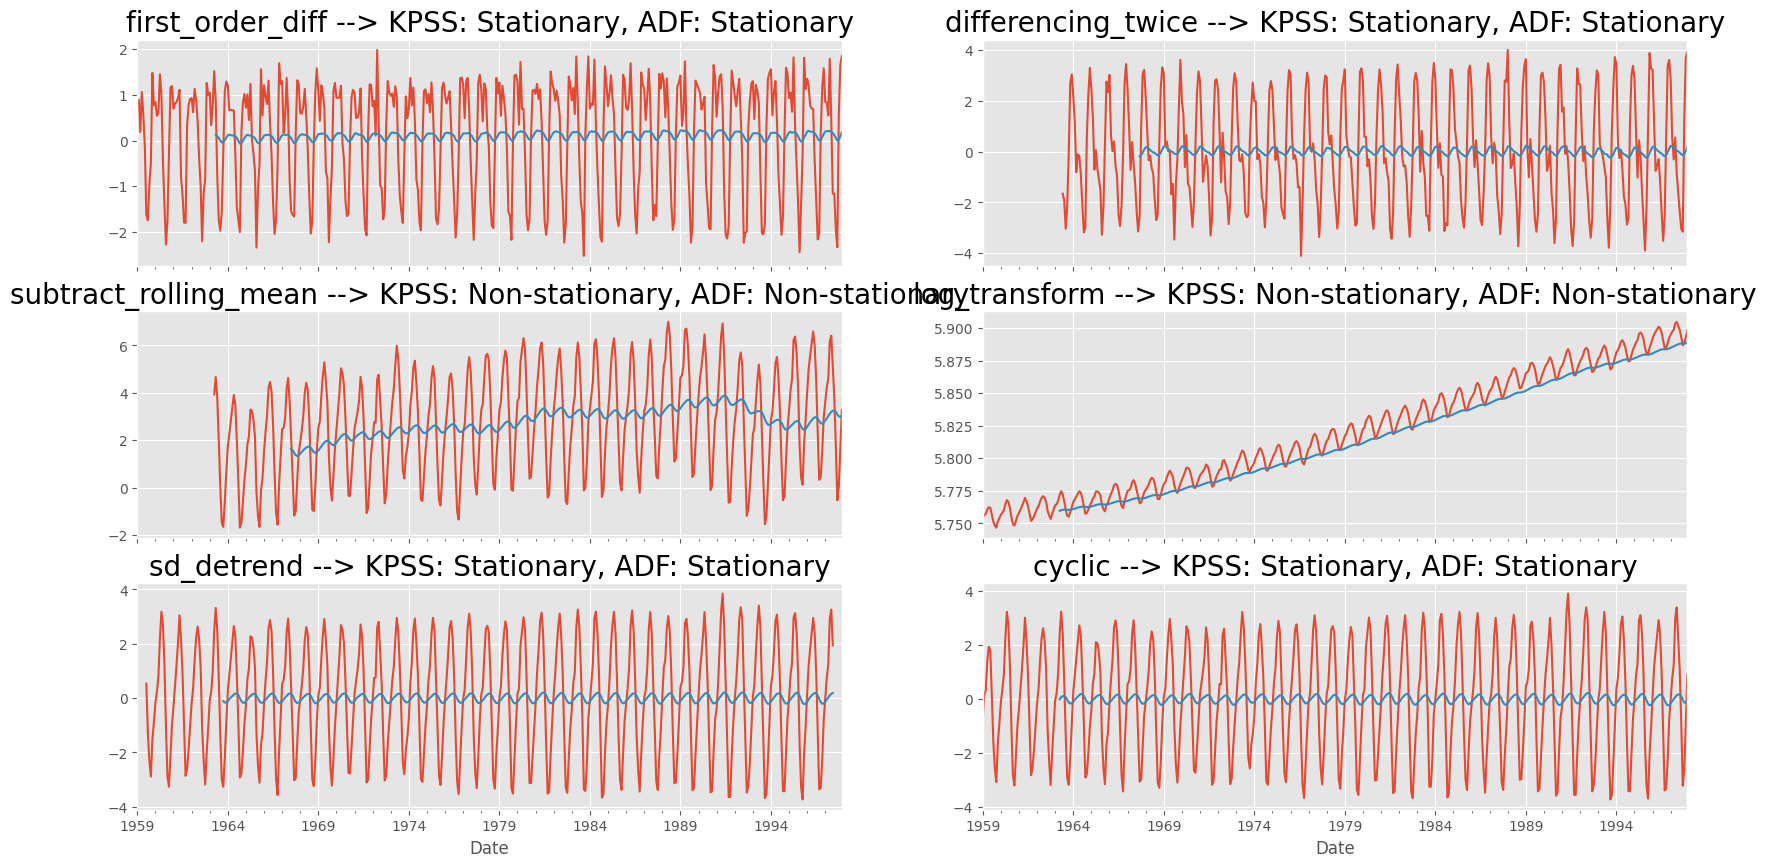

In [137]:
methods = [first_order_diff, differencing_twice, subtract_rolling_mean,
           log_transform, sd_detrend, cyclic]

plot_comparison(methods)

Generally, you do not want to over-difference your time series as some studies have shown
that models based on over-differenced data are less accurate. For example, first_order_diff already made the time series stationary, and thus there was no need to difference it any further. In other words, differencing_twice was not needed.

Additionally, notice how log_transform is still non-stationary. Notice the center line representing the time series average (moving average). The mean should be constant for a stationary time series and look more like a straight line.

Both ADF and KPSS use **Ordinary Least Squares** (**OLS**) regression. More specifically, OLS regression is used to compute the model's coefficients. To view the OLS results for ADF, you use the store parameter and set it to ***True***:

In [138]:
adf_result = adfuller(first_order_diff, store=True)

adf_result[-1].resols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.881
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     251.4
Date:                Fri, 03 Jan 2025   Prob (F-statistic):          3.20e-194
Time:                        23:31:37   Log-Likelihood:                -124.63
No. Observations:                 454   AIC:                             277.3
Df Residuals:                     440   BIC:                             334.9
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -1.5967      0.311     -5.138      0.000      -2.207      -0.986
x2             0.4092      0.299      1.369      0.172      -0.178       0.997
x3             0.2643      0.277      0.953      0.341      -0.281       0.809
x4             0.0984      0.251      0.392      0.695      -0.395       0.592
x5            -0.0583      0.226     -0.258      0.796      -0.502       0.385
x6            -0.1890      0.199     -0.948      0.344      -0.581       0.203
x7            -0.2800      0.175     -1.599      0.111      -0.624       0.064
x8            -0.4089      0.151     -2.711      0.007      -0.705      -0.112
x9            -0.6123      0.126     -4.861      0.000      -0.860      -0.365
x10           -0.6961      0.102     -6.833      0.000      -0.896      -0.496
x11           -0.8893      0.079    -11.187      0.000      -1.046      -0.733
x12           -0.7830      0.064    -12.242      0.000      -0.909      -0.657
x13           -0.2809      0.047     -6.031      0.000      -0.372      -0.189
const          0.1712      0.036      4.754      0.000       0.100       0.242
==============================================================================
Omnibus:                        0.905   Durbin-Watson:                   2.020
Prob(Omnibus):                  0.636   Jarque-Bera (JB):                0.973
Skew:                           0.041   Prob(JB):                        0.615
Kurtosis:                       2.789   Cond. No.                         82.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

• The Test Statistic value is 0.046 for ADF and 8.18 for KPSS, which are above the 1% critical value threshold. This indicates that the time series is non-stationary. It confirms that you cannot reject the null hypothesis. The critical values for ADF come from a Dickey-Fuller table. Luckily, you do not have to reference the Dickey-Fuller table since all statistical software/libraries that offer the ADF test use the table internally. The same applies to KPSS.

• The p-value result is associated with the test statistic. Generally, you can reject the null hypothesis if the p-value is less than 0.05 (5%). Again, when using ADF, KPSS, or other stationarity tests, make sure to understand the null hypothesis to accurately interpret the results.

• Number of lags represents the number of lags used in the autoregressive process in the test (ADF and KPSS). In both tests, 27 lags were used. Since our CO2 data is weekly, a lag represents 1 week back. So, 27 lags represent 27 weeks in
our data.

• The number of observations used is the number of data points, excluding the number of lags.

• The maximized info criteria are based on the autolag parameter. The default is autolag="aic" for the Akaike information criterion. Other acceptable autolag parameter values are bic for the Bayesian information criterion and t-stat.

## Applying Power Transformations

In [139]:
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (16,5)

array([[<Axes: title={'center': 'CO2'}>]], dtype=object)

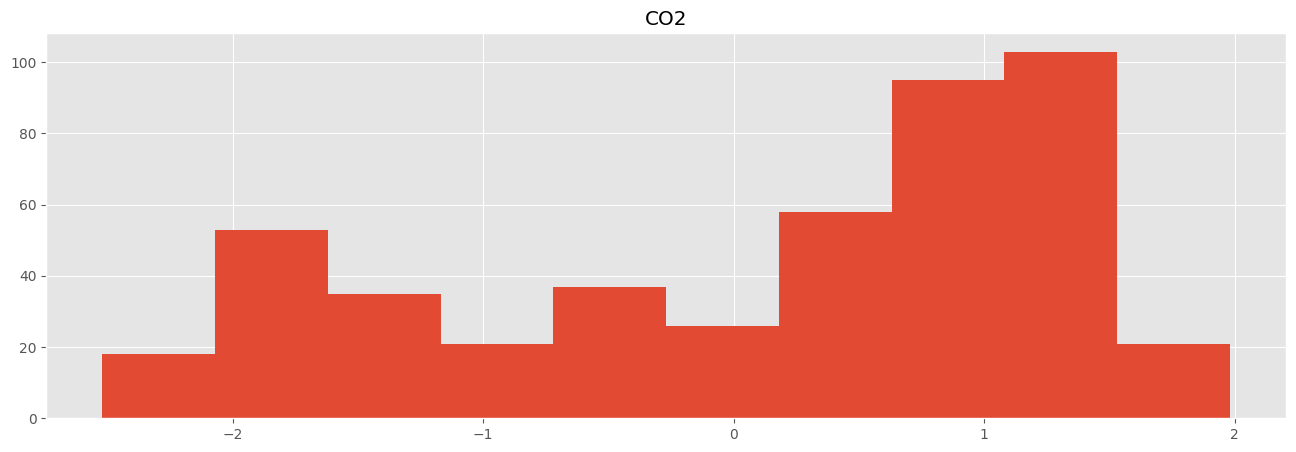

In [140]:
co2_df.diff().hist()

In [141]:
# from statsmodels.tsa.ar_model import AR
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(co2_df.dropna(), lags=1, trend='n').fit()

/home/jeremy/Work/Data Science/Learning/kaggle-ml/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [142]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                    CO2   No. Observations:                  468
Model:                     AutoReg(1)   Log Likelihood                -749.842
Method:               Conditional MLE   S.D. of innovations              1.205
Date:                Fri, 03 Jan 2025   AIC                           1503.684
Time:                        23:31:39   BIC                           1511.976
Sample:                    02-01-1959   HQIC                          1506.947
                         - 12-01-1997                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
CO2.L1         1.0003      0.000   6049.912      0.000       1.000       1.001
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            0.9997           +0.0000j            0.9997            0.0000
-----------------------------------------------------------------------------
"""

### 1. Test for Normality

In [143]:
from scipy.stats import shapiro, kstest, normaltest
from statsmodels.stats.diagnostic import kstest_normal

In [144]:
# The null hypothesis states that the data is normally distributed;
def is_normal(test, p_level=0.05):
    '''
    test: normality tests
    p_level: p-value
    '''
    stat, p_value = test

    return 'Normal' if p_value > 0.05 else 'Not Normal'

In [145]:
normal_args = (np.mean(co2_df),np.std(co2_df))

# Normality tests
print(is_normal(shapiro(co2_df)))     # Shapiro-Wilk Test
print(is_normal(normaltest(co2_df)))   # D'Agostino-Pearson
# print(is_normal(normal_ad(co2_df)))
print(is_normal(kstest_normal(co2_df)))    # Kolmogorov-Smirnov Test
print(is_normal(kstest(co2_df, cdf='norm',args=(np.mean(co2_df), np.std(co2_df)))))   # Kolmogorov-Smirnov Test

Not Normal
Not Normal
Not Normal
Not Normal


/home/jeremy/Work/Data Science/Learning/kaggle-ml/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


(array([ 17.,  53.,  36.,  21.,  37.,  26.,  59.,  95., 102.,  21.]),
 array([-2.62487519, -2.17442683, -1.72397848, -1.27353012, -0.82308176,
        -0.3726334 ,  0.07781495,  0.52826331,  0.97871167,  1.42916003,
         1.87960838]),
 <BarContainer object of 10 artists>)

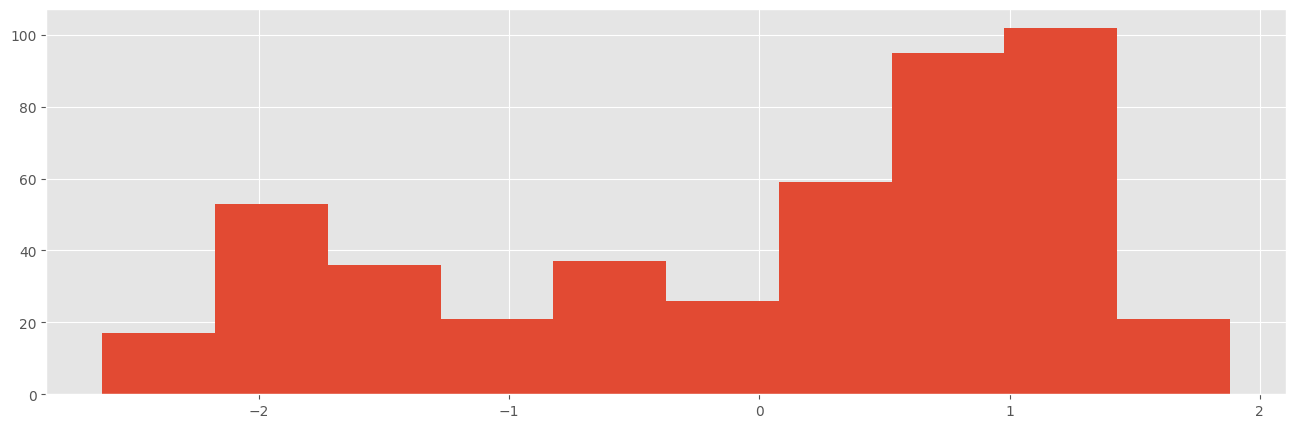

In [146]:
plt.hist(model.resid)

In [147]:
shapiro(co2_df)

ShapiroResult(statistic=np.float64(0.942026889613947), pvalue=np.float64(1.5119371102637876e-12))

In [148]:
model.resid.mean()

np.float64(0.0014767377078237246)

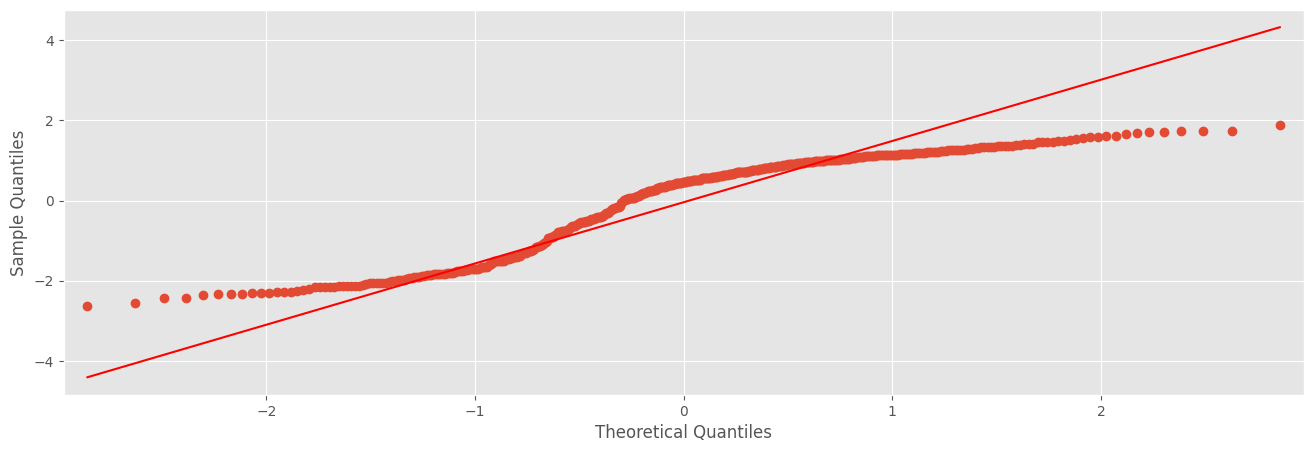

In [149]:
from statsmodels.graphics.gofplots import qqplot

qqplot(model.resid, line='q');

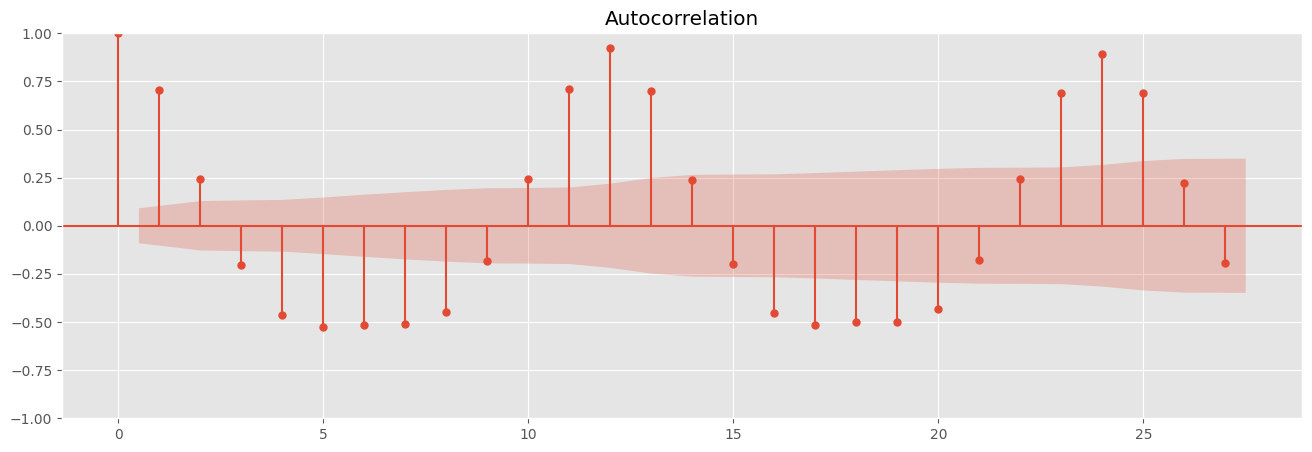

In [150]:
plot_acf(model.resid); plt.show()

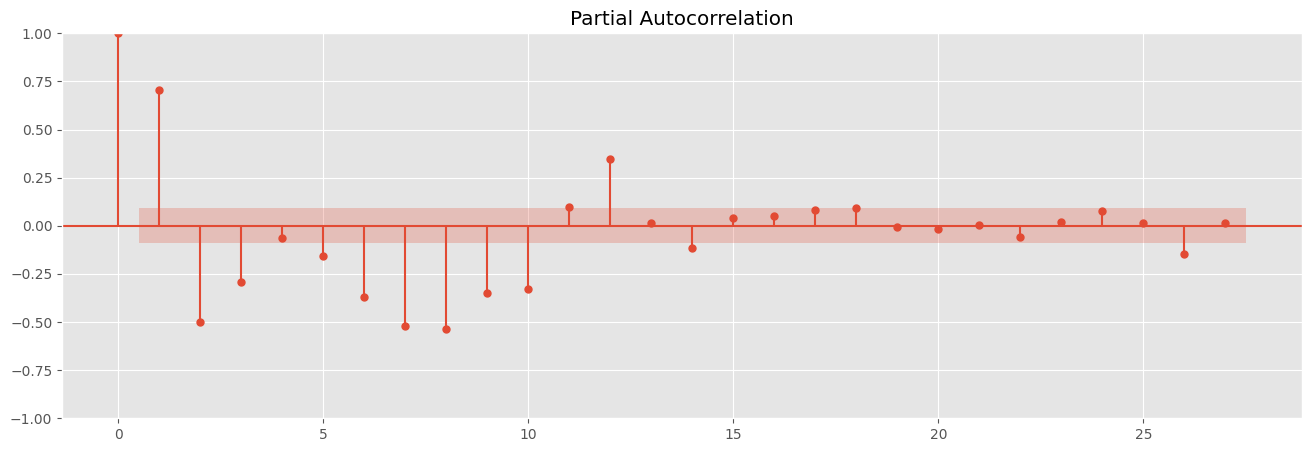

In [151]:
plot_pacf(model.resid); plt.show()

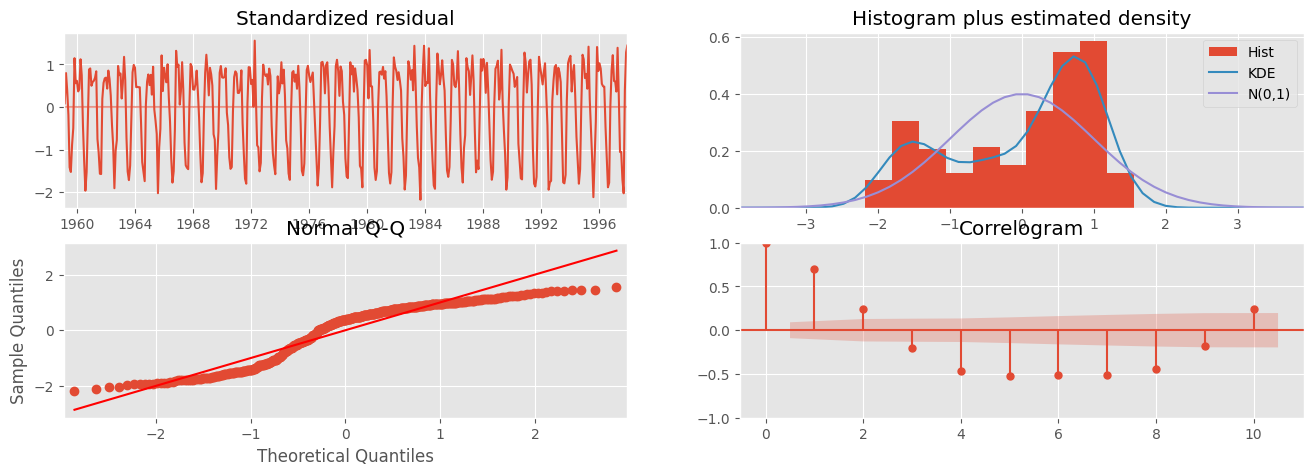

In [152]:
model.plot_diagnostics(); plt.show()

Sometimes, you may need to test normality as part of model evaluation and iagnostics. For example, you would evaluate the residuals (defined as the difference between actual and predicted values) if they follow a normal distribution.

In [153]:
from statsmodels.tsa.api import AutoReg

model = AutoReg(co2_df.ffill(), lags=1).fit()

print(is_normal(shapiro(model.resid)))

Not Normal


/home/jeremy/Work/Data Science/Learning/kaggle-ml/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


The output indicates the residuals are not normally distributed. This fact, residuals not
being normally distributed, is not enough to determine the model's validity or potential
improvements. But taken into context with the other tests, it should help you determine
how good your model is.

In [154]:
model.test_normality()

Jarque-Bera    4.763566e+01
P-value        4.529466e-11
Skewness      -5.864517e-01
Kurtosis       1.964441e+00
dtype: float64

In [155]:
model.test_heteroskedasticity()

,ARCH-LM,P-value,DF
Lag,,,
1,31.937522,1.592118e-08,1
2,56.203398,6.245787e-13,2
3,56.405962,3.441184e-12,3
4,56.703857,1.427416e-11,4
5,71.413147,5.205129e-14,5
6,111.517910,9.803185e-22,6
7,110.019414,9.097685e-21,7
8,120.227722,2.975105e-22,8
9,153.592193,1.588200e-28,9


### 2. Testing Homeskedasticity (Homoscedasticity)

You will be testing for the stability of the variance against the model's residuals. This will
be the same AR(1) model used in the previous normality test:

In [156]:
from statsmodels.stats.api import (het_breuschpagan, het_goldfeldquandt, het_white, het_arch)

def het_test(model, test=""):
    '''
    model: model for testing heteroscedasticity
    test: the type of test to be used for normality
    '''
    lm, lm_p_value, f_value, f_p_value = (
        test(model.resid, sm.add_constant(model.fittedvalues))
    )

    return "Heteroscedastic" if f_p_value < 0.05 else "Homoscedastic"

In [157]:
het_test(model, test=het_breuschpagan)

'Heteroscedastic'

In [158]:
het_test(model, test=het_white)

'Heteroscedastic'

Therefore, we se see the model to be heteroscedastic with non-constant variance.

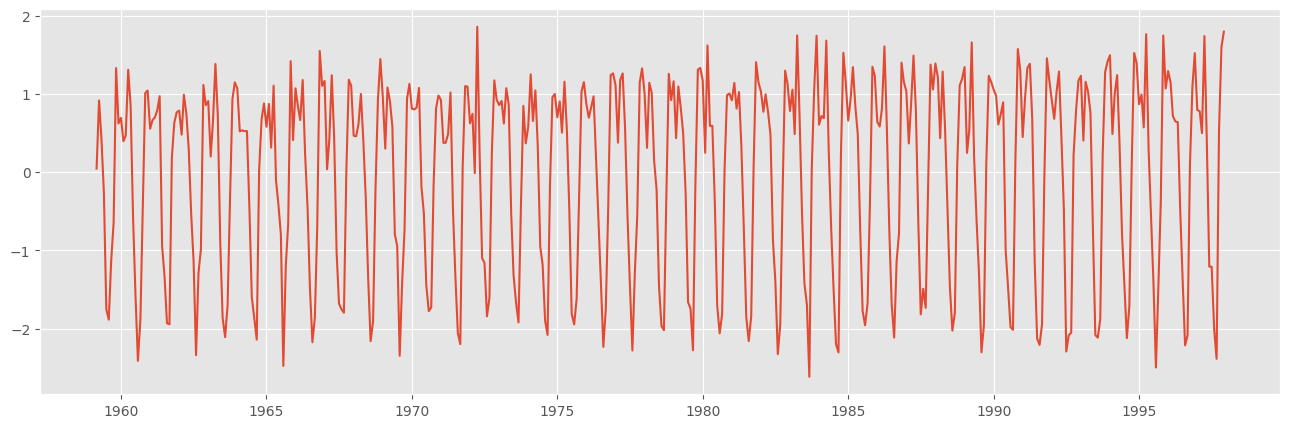

In [159]:
plt.plot(model.resid[1:])

### 3. Applying Box-Cox Transform

**Box-Cox** transforms a non-normally distributed dataset into a normally distributed one. At the same time, it stabilizes the variance, making the data homoskedastic.

In [160]:
from scipy.stats import boxcox

In [161]:
xt, lmbda = boxcox(air_df['value'])
xts = pd.Series(xt, index=air_df.index)

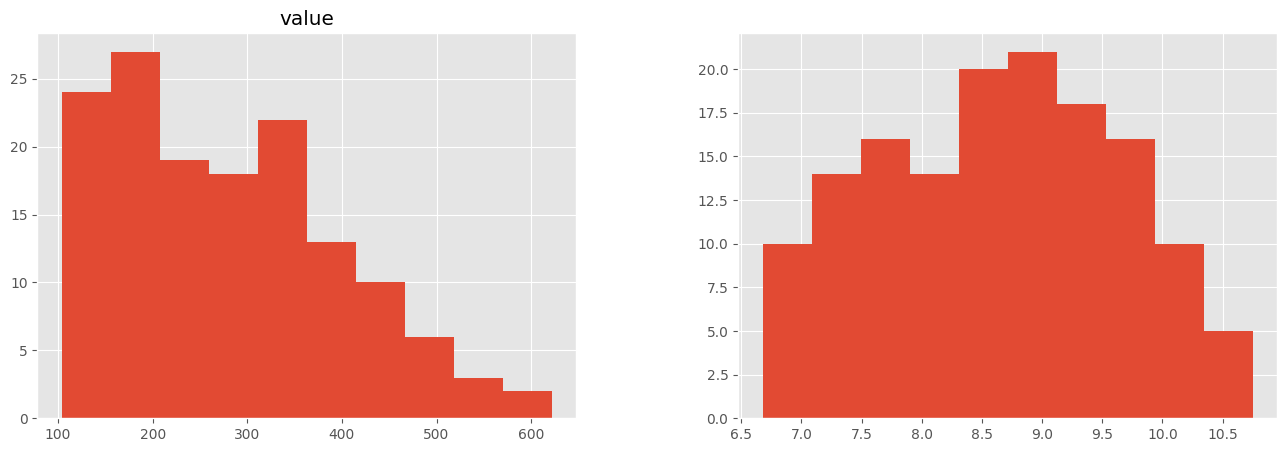

In [162]:
fig, ax = plt.subplots(1, 2)
air_df.hist(ax=ax[0])
xts.hist(ax=ax[1])
plt.show()

The second histogram shows that the data was transformed, and the overall distribution changed. It would be interesting to examine the dataset as a time series plot.

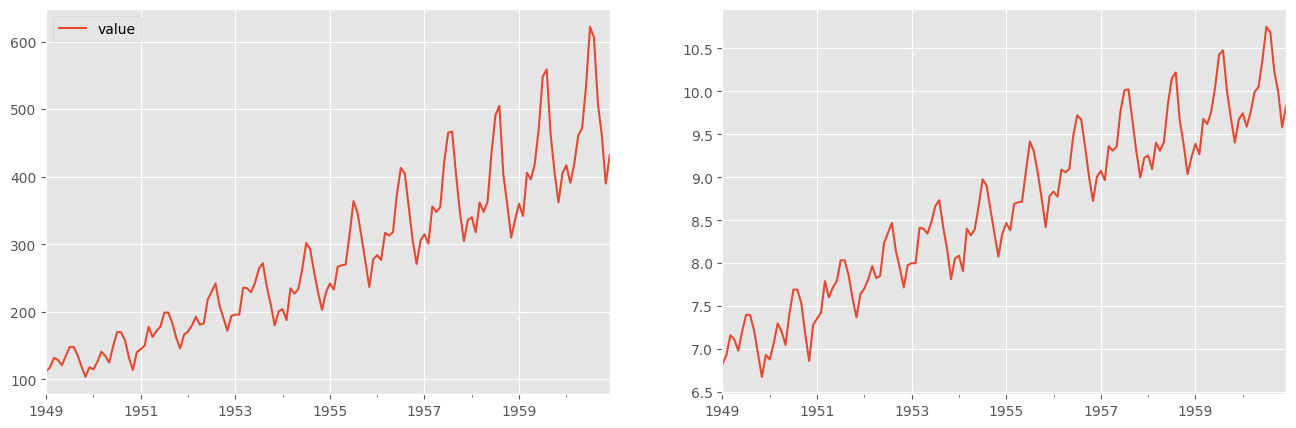

In [163]:
fig, ax = plt.subplots(1, 2)
air_df.plot(ax=ax[0])
xts.plot(ax=ax[1])
plt.show()

Notice how the seasonal effect on the transformed dataset looks more stable
than before.

-----

Finally, build two simple autoregressive models to compare the effect on the residuals before and after the transformation:

<Axes: >

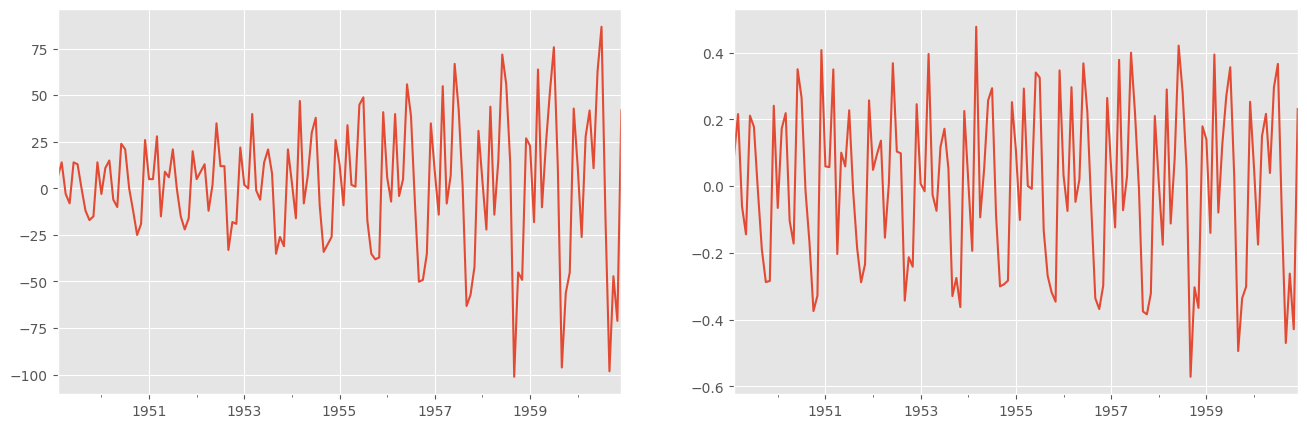

In [164]:
model_airp = AutoReg(air_df, lags=1, trend='n').fit()
model_bx = AutoReg(xts, lags=1, trend='n').fit()
fig, ax = plt.subplots(1, 2)
model_airp.resid.plot(ax=ax[0])
model_bx.resid.plot(ax=ax[1])

In [165]:
print(model_bx.diagnostic_summary())

             Test of Normality              
Jarque-Bera    P-value   Skewness   Kurtosis
--------------------------------------------
      5.987      0.050     -0.128      2.031


    Test of Conditional Homoskedasticity   
       Lag    ARCH-LM    P-value         DF
-------------------------------------------
         1      0.116      0.733          1
         2      1.243      0.537          2
         3      4.112      0.250          3
         4      4.058      0.398          4
         5      6.836      0.233          5
         6      7.203      0.302          6
         7     14.755      0.039          7
         8     15.157      0.056          8
         9     15.993      0.067          9
        10     17.963      0.056         10
-------------------------------------------


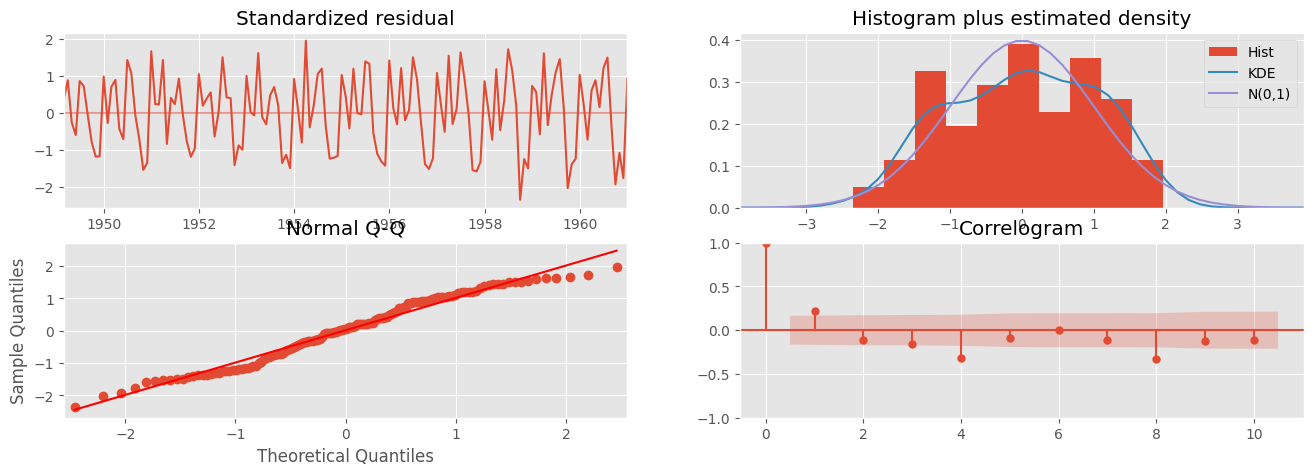

In [166]:
model_bx.plot_diagnostics(); plt.show()

## Test for Autocorrelation in time series data

**Autocorrelation** is like statistical correlation (Pearson correlation), which measures the strength of a linear relationship between two variables, except that we measure the linear relationship between time series values separated by a lag. In other words, we are comparing a variable with its lagged version of itself.

In this recipe, you will perform a **Ljung-Box** test to check for autocorrelations up to a specified lag and whether they are significantly far off from 0. The null hypothesis for the Ljung-Box test states that the previous lags are not correlated with the current period. In other words, you are testing for the absence of autocorrelation. 

When running the test using ***acorr_ljungbox*** from statsmodels, you need to provide a lag value. The test will run for all lags up to the specified lag (maximum lag).

The autocorrelation test is another helpful test for model diagnostics. As discussed in the
previous recipe, Applying power transformations, there are assumptions that you need to test against the model's residuals. For example, when testing for autocorrelation on the residuals, the expectation is that there should be no autocorrelation between the residuals.
This ensures that the model has captured all the necessary information. The presence of
autocorrelation in the residuals can indicate that the model missed an opportunity to capture critical information and will need to be evaluated

In [167]:
from statsmodels.stats.diagnostic import (acorr_breusch_godfrey, acorr_ljungbox, acorr_lm)

co2_diff = np.log(co2_df).diff().dropna()

In [168]:
acorr_ljungbox(co2_diff, lags=10, return_df=True)

,lb_stat,lb_pvalue
1,232.478944,1.716875e-52
2,260.335972,2.942809e-57
3,280.459701,1.684090e-60
4,380.896807,3.727013e-81
5,510.844717,3.641491e-108
6,635.609389,4.843938e-134
7,759.448088,1.042073e-159
8,855.135695,2.676441e-179
9,870.892183,1.154219e-181
10,898.936548,1.078617e-186


In [169]:
acorr_ljungbox(model_bx.resid, return_df=True, lags=10)

,lb_stat,lb_pvalue
1,6.891378,8.661249e-03
2,8.799865,1.227817e-02
3,12.728605,5.261832e-03
4,28.039694,1.224400e-05
5,29.201880,2.116596e-05
6,29.204900,5.563814e-05
7,31.021142,6.161814e-05
8,47.991783,9.915325e-08
9,50.468157,8.794756e-08
10,52.247451,1.026842e-07
